<a href="https://colab.research.google.com/github/Ronaa-MX/simulacion-esfm/blob/simulacion-I/Simulaci%C3%B3nTinasTIBSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simulación de empresa TIBASA

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

![Distribución de triangular de los pesos de las tinas](tinas.png)

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

### Variables Aleatorias
Vemos que dado que las variables aleatorias seran el peso de cada tina, teniendo con paramétros $a=190$, siendo el caso de peso mínimo, $b=230$ el peso máximo y $c=210$ el peso mediano entre los dos otros casos.
$$
X_{i}\sim T(190,230,210) \text{ Siendo  i}=\text{1,2,3,4,5}
$$
Entonces tendremos que para conocer el peso de las tinas total, debera ser que tengamos que debe ser la suma de las cinco variables aleatorias
$$
S=\sum_{i=1}^{5}X_{i}
$$

In [14]:
# Librearías a utilizar 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from multiprocessing import Pool
import time #Medir tiempo de simulación


In [15]:
# ------------------------------------------------------------
# 1. Identificar las variables aleatorias del modelo
# ------------------------------------------------------------
# Variable: peso de cada tina (X_i) y peso total (S = sum(X_i))

# ------------------------------------------------------------
# 2. Determinar la distribución de probabilidad
# ------------------------------------------------------------
# Cada X_i ~ Triangular(190, 230, 210) (simétrica)

# ------------------------------------------------------------
# 3. Modelar las variables aleatorias
# ------------------------------------------------------------
# Usamos numpy.random.triangular(left, mode, right)
def generar_pesos_tinas(n_tinas=5):
    """Genera n_tinas pesos independientes con distribución triangular."""
    return np.random.triangular(190, 210, 230, size=n_tinas)

In [28]:
# ------------------------------------------------------------
# 4. Definir el modelo del sistema y objetivos de simulación
# ------------------------------------------------------------
# Sistema: camión transporta 5 tinas → peso total S
# Objetivo: estimar p = P(S > 1000)

# ------------------------------------------------------------
# 5. Diseñar el experimento
# ------------------------------------------------------------
# Realizaremos un número creciente de experimentos (hasta N_total)
# para observar convergencia y luego fijar N suficiente.
N_total = 250000   # Número total de experimentos (se puede ajustar)
resultados = np.zeros(N_total)   # 1 si S > 1000, 0 en caso contrario

# ------------------------------------------------------------
# 6. Repetir el experimento n veces
# ------------------------------------------------------------
def exp_tinas(N_total):
    for i in range(N_total):
        pesos = generar_pesos_tinas(5)
        total = np.sum(pesos)
        resultados[i] = 1 if total > 1000 else 0
    return resultados

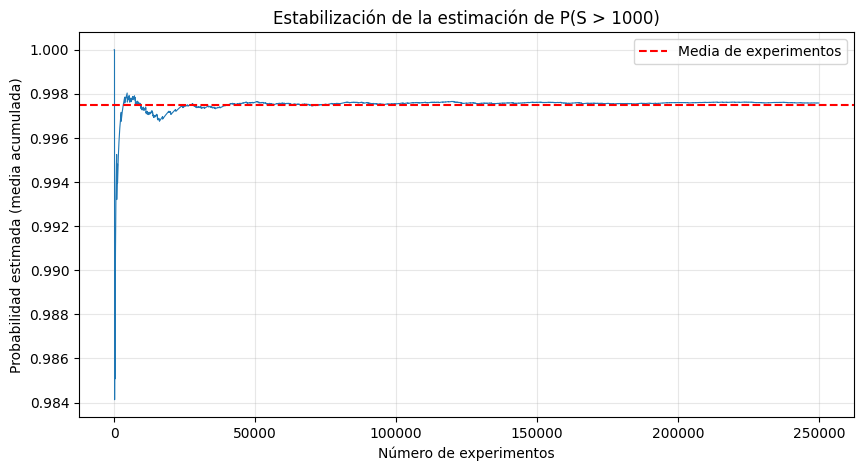

In [39]:
# ------------------------------------------------------------
# 7. Gráfica de estabilización (media acumulada)
# ------------------------------------------------------------
acum_mean = np.cumsum(exp_tinas(N_total)) / np.arange(1, N_total+1)

plt.figure(figsize=(10,5))
plt.plot(acum_mean, linewidth=0.8)
plt.xlabel('Número de experimentos')
plt.ylabel('Probabilidad estimada (media acumulada)')
plt.title('Estabilización de la estimación de P(S > 1000)')
plt.grid(alpha=0.3)
plt.axhline(y=np.mean(exp_tinas(N_total)), color='r', linestyle='--', label='Media de experimentos')
plt.legend()
plt.show()


Ejecutando 1000 réplicas, cada una con 250000 experimentos...


Tiempo total (paralelo): 28.44 segundos


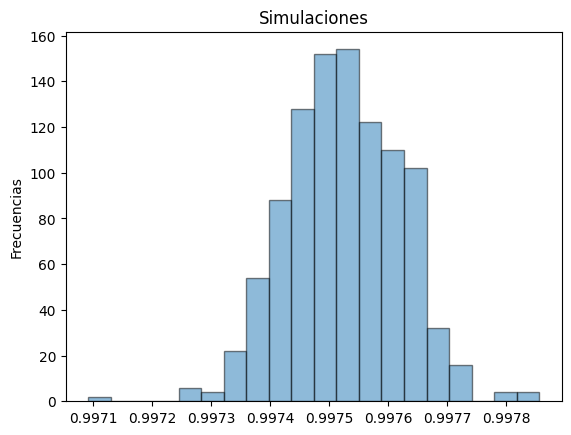

In [41]:
# Según la gráfica, con N ~ 50000 la estimación ya es estable.
# Tomamos N_final = 250000 para mayor precisión.

# ------------------------------------------------------------
# 8. Replicar el modelo con simulación
# ------------------------------------------------------------
# En este caso ya tenemos una ejecución larga.
# Podríamos replicar varias veces para evaluar variabilidad,
# pero el intervalo de confianza ya proporciona esa información.
n_trials=250000
def tina_replica(n_trials):
    """
    Función que ejecuta una réplica completa:
    - Genera 'n' experimentos de transporte (cada día 5 tinas)
    - Retorna la probabilidad estimada en esa réplica
    """
    # Vectorizado: matriz de (n, 5) con pesos triangulares
    tinas = np.random.triangular(190, 210, 230, size=(n_trials, 5))
    pesos_totales = np.sum(tinas, axis=1)
    prob = np.mean(pesos_totales > 1000)
    return prob

# Número de réplicas (suficiente para intervalo de confianza)

M = 1000
def sim_tina(M,n_trials):
    print(f"\nEjecutando {M} réplicas, cada una con {n_trials} experimentos...")
    inicio = time.time()

    # Paralelización con multiprocessing.Pool
    with Pool() as pool:
        estimaciones = pool.map(tina_replica, [n_trials] * M)

    duracion = time.time() - inicio
    print(f"Tiempo total (paralelo): {duracion:.2f} segundos")
    return estimaciones

tinas_sim = sim_tina(M,n_trials)
plt.hist(tinas_sim, bins=20,edgecolor="black",alpha=.5)
plt.title("Simulaciones")
plt.ylabel("Frecuencias")
plt.show()

In [42]:
# ------------------------------------------------------------
# 9. Calcular la probabilidad buscada por simulación
# ------------------------------------------------------------

mean_hat = np.mean(tinas_sim).item()
std_hat = np.std(tinas_sim).item()
var_hat = np.var(tinas_sim).item()
print(f"La media de las simulaciones (con {M} simulaciones): {mean_hat:.4f}")
print(f"La desviación estándar de las simulaciones (con {M} simulaciones): {std_hat:.6f}")
print(f"La varianza de las simulaciones (con {M} simulaciones): {var_hat:.6f}")

# ------------------------------------------------------------
# 10. Intervalo de confianza del 95%
# ------------------------------------------------------------
z = 1.96
error = z * np.sqrt(mean_hat * (1 - mean_hat) / n_trials)
ic_inf = mean_hat - error
ic_sup = mean_hat + error
print(f"Intervalo de confianza del 95%: ({ic_inf:.4f}, {ic_sup:.4f})")

La media de las simulaciones (con 1000 simulaciones): 0.9975
La desviación estándar de las simulaciones (con 1000 simulaciones): 0.000097
La varianza de las simulaciones (con 1000 simulaciones): 0.000000
Intervalo de confianza del 95%: (0.9973, 0.9977)


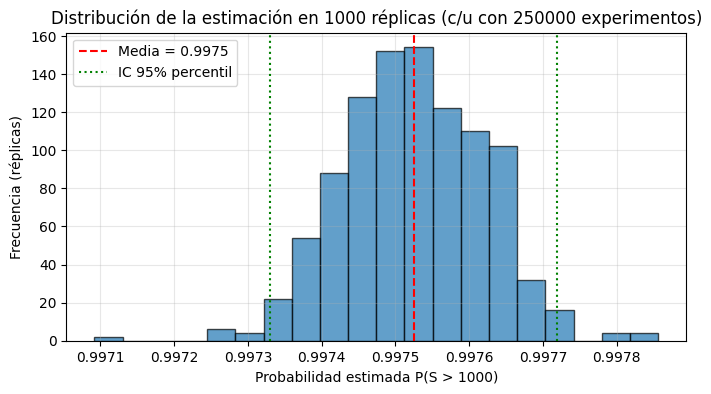

In [43]:
# Opcional: Histograma de las estimaciones de cada réplica
plt.figure(figsize=(8,4))
plt.hist(tinas_sim, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_hat, color='red', linestyle='--', label=f'Media = {mean_hat:.4f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95% percentil')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.xlabel('Probabilidad estimada P(S > 1000)')
plt.ylabel('Frecuencia (réplicas)')
plt.title(f'Distribución de la estimación en {M} réplicas (c/u con {n_trials} experimentos)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Solución Analítica

Tendremos que dada la variable aleatoria $S$, considerando cómo la suma de la variables aleatorias de los pesos de los cinco tina, similares a una distribución triangular con paramétros $a=190$, siendo el caso de peso mínimo, $b=230$ el peso máximo y $c=210$ el peso mediano entre los dos otros casos. Bajo el teorema del límite central, considerando a estas variables cómo independientes e identicamente distribuidas, sera que puede aproximarse la probabilidad de encontrar cuando sean mayor a una $1$ T, $P(S>1000)$, consideraremos que se acerca $S$ a una normal. Siendo $\mu=210$ y $\sigma^2=\frac{(b-a)^2}{24}=66.\bar{6}$, para cada variable aleatoria $X_{i}$, el peso de una de las cinco tinas. Entonces tendremos que considerando a $S\sim N(\mu_{S},\sigma^2_{S})$, siendo por linealidad tanto de la esperanza y la varianza tendremos que $\mu_{S}=5\mu=1050$ y con $\sigma^2_{S}=5\times \sigma^2=5\times\frac{200}{3}=333.\bar{6}$. Entonces para poder encontra la probabilidad 
$$
P(S>1000),
$$
condideramos que dado que $S$, se aproxima a la normal por el teorema del límite central, entonces prodremos normalizarla a una $Z$, siendo entonces la probabilidad sera 
$$
P(S>1000)=1-Z\left(\frac{1000-\mu_{S}}{\sqrt{\sigma^2_{S}}}\right).
$$

Siendo entonces el valor de la probabilidad cuando sea que el peso de cinco tinas sea mayor a $1$ T, sera que tendremos que $Z=-2.73$, sera que tendremos que es 
$$
P(S>1000)=1-Z(-2.73)=Z(2.73)=0.997
$$
Por lo tanto la probabilidad de que la suma de los cinco pesos de las tinas sea mayor a $1$ tonlada, sera que $P(S>1000)=0.997$.